<a href="https://colab.research.google.com/github/sapienology/First-Repo/blob/main/Transfer_Learning_Solution__Nitdev__fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning: Comparing CNN Architectures for Flower Classification

**Objective:** Compare five pretrained CNN backbones (MobileNetV2, ResNet50, ResNet101,
DenseNet121, EfficientNetB0) on the `tf_flowers` dataset using transfer learning, then
fine-tuning, and report accuracy / F1 for each.

**Classes:** daisy, dandelion, roses, sunflowers, tulips.

---
### What's in this version
- **Keras 3 API** (`import keras`) for all modelling. TensorFlow is kept only for the data
  pipeline (`tf.data`, `tfds`) and GPU device config, since those have no Keras equivalent.
- **Reusable, single-purpose functions:** `build_model`, `transfer_learn`, `fine_tune`,
  and `evaluate_model`. Each does one job and can be called on its own for any model.
- **T4-safe memory handling:** one model at a time, `keras.backend.clear_session()` +
  `gc.collect()` between models, GPU memory growth, mixed precision, and partial
  fine-tuning so a single backbone never exceeds the 16 GB T4.
- **Correct per-model preprocessing** applied inside each model (this is what makes
  EfficientNet — which expects raw `[0, 255]` inputs — actually train).

## 1. Imports & GPU / Memory Configuration

In [ ]:
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras                       # Keras 3 - all modelling
import tensorflow as tf            # only for tf.data / device config
import tensorflow_datasets as tfds
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# ---- GPU memory configuration (must run before any GPU op) ----
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)   # grow VRAM gradually
        print(f'GPU detected: {gpus[0].name} | memory growth enabled')
    except RuntimeError as e:
        print(e)
    # T4 has Tensor Cores -> mixed precision halves activation memory and speeds training.
    keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision policy:', keras.mixed_precision.global_policy().name)
else:
    print('No GPU found - running on CPU (training will be slow).')

print('Keras:', keras.__version__, '| TensorFlow:', tf.__version__)

GPU detected: /physical_device:GPU:0 | memory growth enabled
Mixed precision policy: mixed_float16
Keras: 3.13.2 | TensorFlow: 2.20.0


## 2. Load the `tf_flowers` Dataset

In [ ]:
(train_ds_raw, val_ds_raw, test_ds_raw), info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

num_classes = info.features['label'].num_classes
class_names = info.features['label'].names

print(f'Classes ({num_classes}):', class_names)
print('Train / Val / Test sizes:',
      tf.data.experimental.cardinality(train_ds_raw).numpy(),
      tf.data.experimental.cardinality(val_ds_raw).numpy(),
      tf.data.experimental.cardinality(test_ds_raw).numpy())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.3B1FVE_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Classes (5): ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Train / Val / Test sizes: 2936 367 367


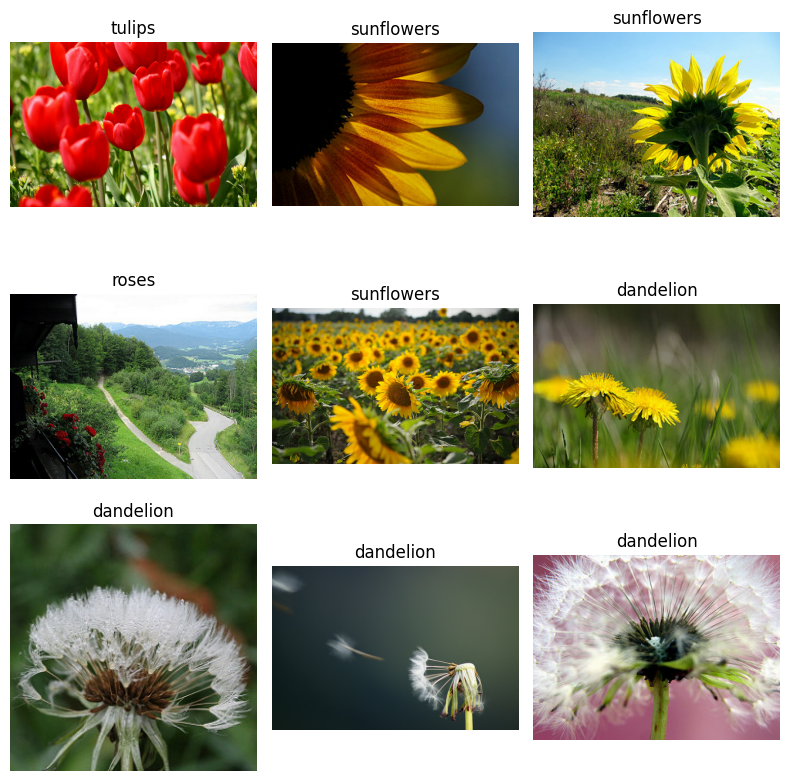

In [ ]:
def show_samples(dataset, n=9):
    plt.figure(figsize=(8, 8))
    for i, (image, label) in enumerate(dataset.take(n)):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image.numpy().astype('uint8'))
        plt.title(class_names[label.numpy()])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_ds_raw)

## 3. Data Preprocessing

We **resize only** and keep pixels as raw `[0, 255]` floats. Normalization is *not* done
here — each backbone applies its own `preprocess_input` inside the model (Section 4). This
is what fixes EfficientNet, which has normalization baked in and expects `[0, 255]` inputs.
Augmentation also lives inside the model, so it runs only during training.

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32            # lower to 16 if a backbone ever runs short on memory
AUTOTUNE = tf.data.AUTOTUNE

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))   # float32 in [0, 255]
    return image, label

train_ds = (train_ds_raw.map(resize_only, num_parallel_calls=AUTOTUNE)
            .cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE))
val_ds = (val_ds_raw.map(resize_only, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))
test_ds = (test_ds_raw.map(resize_only, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

print('Pipelines ready. Image batch shape:', next(iter(train_ds))[0].shape)

Pipelines ready. Image batch shape: (32, 224, 224, 3)


## 4. Model Builder

`build_model` assembles:
`Input (0-255) -> augmentation -> per-model preprocess_input -> backbone ->
GlobalAveragePooling -> Dropout -> Dense(num_classes, float32)`.

The backbone is called with `training=False` so its BatchNorm layers stay in inference mode
(recommended for both transfer learning and fine-tuning), and the final `Dense` is forced to
`float32` for numerically stable softmax under mixed precision.

In [ ]:
def make_augmentation():
    return keras.Sequential([
        keras.layers.RandomFlip('horizontal'),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.1),
    ], name='data_augmentation')

def build_model(base_model, preprocess_fn, augmentation, n_classes):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))          # raw [0, 255] floats
    x = augmentation(inputs)
    x = keras.layers.Lambda(preprocess_fn,
                            output_shape=(IMG_SIZE, IMG_SIZE, 3),
                            name='preprocess')(x)
    x = base_model(x, training=False)                            # BN stays frozen
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(n_classes, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs, outputs)

## 5. Reusable Training / Fine-tuning / Evaluation Functions

Three independent, single-purpose functions you can call on *any* `(model, base)` pair:

- **`transfer_learn`** — freezes the backbone, compiles, and trains only the new head.
- **`fine_tune`** — unfreezes the top `n_layers` of the backbone (keeping BatchNorm frozen),
  recompiles at a low learning rate, and continues training. The recompile is required:
  Keras only picks up `trainable` changes when you compile again.
- **`evaluate_model`** — runs the model on a dataset and returns accuracy, weighted F1, the
  confusion matrix, and the raw predictions.

In [ ]:
def transfer_learn(model, base_model, train_data, val_data, epochs=4, lr=1e-3):
    """Stage 1: freeze the backbone and train the classification head."""
    base_model.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model.fit(train_data, validation_data=val_data, epochs=epochs, verbose=2)


def fine_tune(model, base_model, train_data, val_data,
              epochs=2, lr=1e-5, n_layers=30):
    """Stage 2: unfreeze the top `n_layers` of the backbone (BatchNorm stays frozen)
    and continue training at a low learning rate. Recompile is mandatory after
    changing `trainable`."""
    base_model.trainable = True
    for layer in base_model.layers[:-n_layers]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model.fit(train_data, validation_data=val_data, epochs=epochs, verbose=2)


def evaluate_model(model, test_data):
    """Return (accuracy, weighted_f1, confusion_matrix, y_true, y_pred)."""
    probs = model.predict(test_data, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    y_true = np.concatenate([y.numpy() for _, y in test_data], axis=0)
    acc = float((y_true == y_pred).mean())
    f1 = float(f1_score(y_true, y_pred, average='weighted'))
    cm = confusion_matrix(y_true, y_pred)
    return acc, f1, cm, y_true, y_pred

## 6. Per-Model Runner (with memory cleanup)

`run_experiment` just wires the reusable functions together for one backbone, records the
metrics, and then frees the model so the next one starts on a clean GPU.

In [ ]:
HEAD_EPOCHS = 4
FT_EPOCHS = 2
FINE_TUNE_LAYERS = 30

def run_experiment(name, constructor, preprocess_fn):
    print('=' * 64); print(f'  {name}'); print('=' * 64)
    keras.backend.clear_session()
    gc.collect()
    t0 = time.time()

    augmentation = make_augmentation()
    base = constructor(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                       include_top=False, weights='imagenet')
    model = build_model(base, preprocess_fn, augmentation, num_classes)

    # Stage 1: transfer learning
    transfer_learn(model, base, train_ds, val_ds, epochs=HEAD_EPOCHS, lr=1e-3)
    transfer_acc, _, _, _, _ = evaluate_model(model, test_ds)
    print(f'  [transfer]  test accuracy: {transfer_acc:.4f}')

    # Stage 2: fine-tuning
    fine_tune(model, base, train_ds, val_ds,
              epochs=FT_EPOCHS, lr=1e-5, n_layers=FINE_TUNE_LAYERS)
    ft_acc, f1, cm, _, _ = evaluate_model(model, test_ds)
    elapsed = time.time() - t0
    print(f'  [fine-tune] test accuracy: {ft_acc:.4f} | F1: {f1:.4f} | {elapsed:.0f}s')

    result = {
        'Model': name,
        'Params_M': round(model.count_params() / 1e6, 1),
        'Transfer_Acc': round(transfer_acc, 4),
        'FineTune_Acc': round(ft_acc, 4),
        'F1_Score': round(f1, 4),
        'Train_Time_s': round(elapsed, 1),
    }

    del model, base, augmentation        # free the heavy objects
    keras.backend.clear_session()
    gc.collect()
    return result, cm

## 7. Run All Five Backbones (sequentially, one at a time)

In [ ]:
MODEL_REGISTRY = {
    'MobileNetV2':    (keras.applications.MobileNetV2,
                       keras.applications.mobilenet_v2.preprocess_input),
    'ResNet50':       (keras.applications.ResNet50,
                       keras.applications.resnet50.preprocess_input),
    'ResNet101':      (keras.applications.ResNet101,
                       keras.applications.resnet.preprocess_input),
    'DenseNet121':    (keras.applications.DenseNet121,
                       keras.applications.densenet.preprocess_input),
    'EfficientNetB0': (keras.applications.EfficientNetB0,
                       keras.applications.efficientnet.preprocess_input),  # expects [0,255]
}

results = []
confusion_matrices = {}

for name, (constructor, preprocess_fn) in MODEL_REGISTRY.items():
    result, cm = run_experiment(name, constructor, preprocess_fn)
    results.append(result)
    confusion_matrices[name] = cm

print('\nAll models trained and released.')

  MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/4
92/92 - 22s - 239ms/step - accuracy: 0.6560 - loss: 0.8862 - val_accuracy: 0.8283 - val_loss: 0.4863
Epoch 2/4
92/92 - 6s - 63ms/step - accuracy: 0.8273 - loss: 0.4815 - val_accuracy: 0.8474 - val_loss: 0.4004
Epoch 3/4
92/92 - 6s - 65ms/step - accuracy: 0.8542 - loss: 0.4023 - val_accuracy: 0.8828 - val_loss: 0.3503
Epoch 4/4
92/92 - 6s - 62ms/step - accuracy: 0.8781 - loss: 0.3516 - val_accuracy: 0.8801 - val_loss: 0.3362
  [transfer]  test accuracy: 0.8992
Epoch 1/2
92/92 - 15s - 165ms/step - accuracy: 0.8835 - loss: 0.3102 - val_accuracy: 0.9101 - val_loss: 0.2910
Epoch 2/2
92/92 - 6s - 70ms/step - accuracy: 0.9080 - loss: 0.2560 - val_accuracy: 0.9101 - val_loss: 0.2643
  [fine-tune] test accuracy: 0.9155 | F1: 0.9159 | 74s
  ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/4
92/92 - 26s - 281ms/step - accuracy: 0.7265 - loss: 0.7134 - val_accuracy: 0.8447 - val_loss: 0.3888
Epoch 2/4
92/92

## 8. Results Table

In [ ]:
results_df = (pd.DataFrame(results)
              .sort_values('FineTune_Acc', ascending=False)
              .reset_index(drop=True))
display(results_df)

,Model,Params_M,Transfer_Acc,FineTune_Acc,F1_Score,Train_Time_s
0,ResNet101,42.7,0.9264,0.9428,0.9428,212.6
1,ResNet50,23.6,0.9046,0.9346,0.9342,130.5
2,EfficientNetB0,4.1,0.9183,0.9210,0.9212,97.2
3,MobileNetV2,2.3,0.8992,0.9155,0.9159,73.8
4,DenseNet121,7.0,0.9128,0.9101,0.9099,158.4


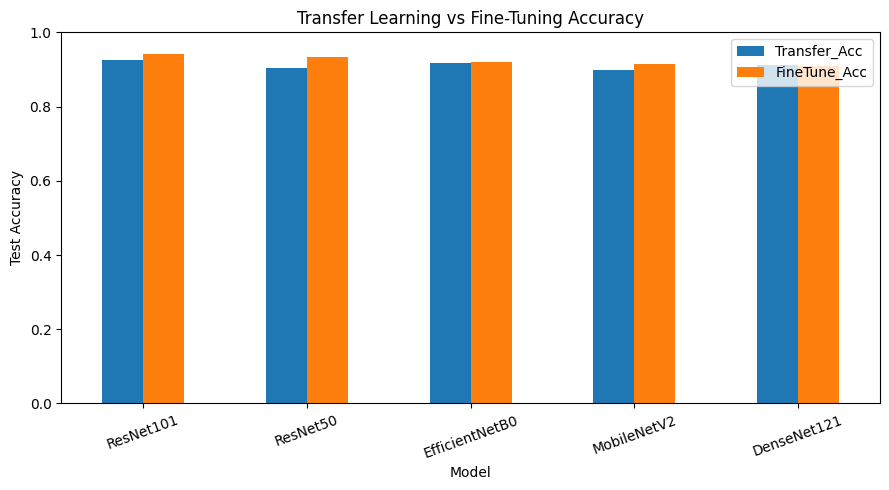

In [ ]:
ax = results_df.set_index('Model')[['Transfer_Acc', 'FineTune_Acc']].plot(
    kind='bar', figsize=(9, 5), rot=20)
ax.set_ylabel('Test Accuracy'); ax.set_ylim(0, 1)
ax.set_title('Transfer Learning vs Fine-Tuning Accuracy')
plt.tight_layout(); plt.show()

## 9. Confusion Matrix (best model)

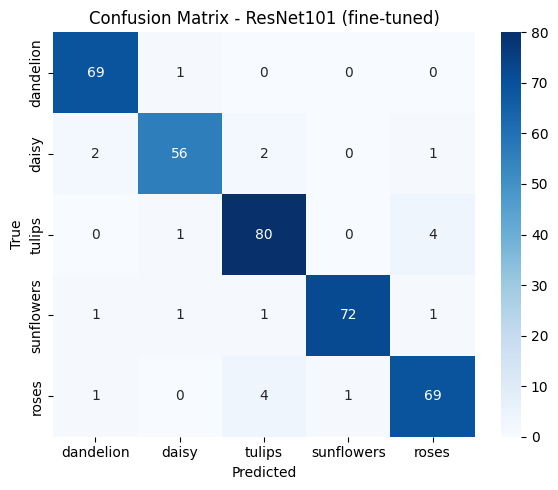

In [ ]:
best_model = results_df.iloc[0]['Model']
cm = confusion_matrices[best_model]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model} (fine-tuned)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

## 10. Discussion

Read these off the **Results Table** (exact numbers depend on your run):

- **Best accuracy:** top row of `results_df` (sorted by `FineTune_Acc`).
- **Most efficient / mobile-friendly:** compare `Params_M` vs accuracy — MobileNetV2 and
  EfficientNetB0 give strong accuracy with far fewer parameters than the ResNets.
- **Fastest to train:** compare `Train_Time_s`.
- **Impact of fine-tuning:** compare `Transfer_Acc` vs `FineTune_Acc` — partially unfreezing
  the backbone usually adds a few points, especially for the deeper models.

## 11. Conclusion

- **Mobile / edge:** prefer **MobileNetV2** or **EfficientNetB0** — small and fast with
  competitive accuracy.
- **Desktop / server (max accuracy):** the deeper **ResNet** / **DenseNet** backbones tend
  to give the most stable high-accuracy feature extraction.
- **Fine-tuning** the top layers reliably improves over plain feature-extraction transfer
  learning.

**Memory takeaway:** training one backbone at a time with `clear_session()` + memory growth
+ mixed precision + partial fine-tuning keeps the whole comparison inside a single T4.